# 01 — EDA + Pipeline Steps 1-4: Sales Forecasting (Pizza + Bakery)

Steps 1-4 (Collection, Cleaning, Preprocessing, Feature Engineering) live here.
Output: app/data/processed/sales_daily.csv — the only thing app/modeling/ reads.
No weather here — Pizza/Bakery item-level data isn't the weather track (see notebook 02).

In [19]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parents[1]))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import joblib

from app.config import (
    PIZZA_ORDERS_CSV, PIZZA_ORDER_DETAILS_CSV, PIZZA_TYPES_CSV, PIZZA_PIZZAS_CSV,
    BAKERY_SALES_CSV,
    PROCESSED_DIR, SALES_DAILY_PROCESSED_CSV, SALES_DAILY_NORMALIZED_CSV,
    FEATURE_SCALER_PATH,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## STEP 1 — Data Collection

Both datasets get loaded into a common shape:
`date | item_name | category | quantity | revenue | source`

Before writing the loaders, check the actual column names —
this is what "learning while creating" means here: don't guess.

In [20]:
print(pd.read_csv(PIZZA_ORDERS_CSV).columns.tolist())
print(pd.read_csv(PIZZA_ORDER_DETAILS_CSV).columns.tolist())
print(pd.read_csv(BAKERY_SALES_CSV).columns.tolist())

['order_id', 'date', 'time']
['order_details_id', 'order_id', 'pizza_id', 'quantity']
['TransactionNo', 'Items', 'DateTime', 'Daypart', 'DayType']


In [30]:
COMMON_COLUMNS = ["date", "item_name", "category", "quantity", "revenue", "source"]

def load_pizza_sales() -> pd.DataFrame:
    orders = pd.read_csv(PIZZA_ORDERS_CSV)
    details = pd.read_csv(PIZZA_ORDER_DETAILS_CSV)
    pizzas = pd.read_csv(PIZZA_PIZZAS_CSV)
    types = pd.read_csv(PIZZA_TYPES_CSV, encoding="latin1")

    df = (
        details.merge(orders, on="order_id")
        .merge(pizzas, on="pizza_id")
        .merge(types, on="pizza_type_id", suffixes=("", "_type"))
    )
    df = df.rename(columns={"name": "item_name", "category": "category"})
    df["date"] = pd.to_datetime(df["date"])
    df["revenue"] = df["quantity"] * df["price"]
    df["source"] = "pizza"
    df["_row_id"] = df["order_details_id"]  # true unique key — one row per order line
    return df[["_row_id"] + COMMON_COLUMNS]


def load_bakery_sales() -> pd.DataFrame:
    """Bakery dataset has no price/quantity column — each row IS one item
    sold. quantity_sold gets built later by counting rows per item per day.
    revenue is genuinely unavailable for this dataset — leave it NaN and
    say so in the findings, don't invent a number."""
    df = pd.read_csv(BAKERY_SALES_CSV)
    df = df.rename(columns={"Items": "item_name", "DateTime": "date"})
    df = df[df["item_name"] != "NONE"]  # known placeholder row in this dataset — not a real sale
    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    df["quantity"] = 1
    df["category"] = "bakery_item"
    df["revenue"] = np.nan
    df["source"] = "bakery"
    # true unique key: same transaction can list the same item twice (2 units
    # bought together) — cumcount tells those apart instead of collapsing them
    df["_row_id"] = (
        df["TransactionNo"].astype(str) + "_"
        + df["item_name"].astype(str) + "_"
        + df.groupby(["TransactionNo", "item_name"]).cumcount().astype(str)
    )
    return df[["_row_id"] + COMMON_COLUMNS]


pizza_df = load_pizza_sales()
bakery_df = load_bakery_sales()
pizza_df.head()

,_row_id,date,item_name,category,quantity,revenue,source
0,1,2015-01-01,The Hawaiian Pizza,Classic,1,13.25,pizza
1,2,2015-01-01,The Classic Deluxe Pizza,Classic,1,16.00,pizza
2,3,2015-01-01,The Five Cheese Pizza,Veggie,1,18.50,pizza
3,4,2015-01-01,The Italian Supreme Pizza,Supreme,1,20.75,pizza
4,5,2015-01-01,The Mexicana Pizza,Veggie,1,16.00,pizza


### EDA — raw data quality check (before any cleaning)

In [32]:
raw_combined = pd.concat([pizza_df, bakery_df], ignore_index=True)

for name, df in [("pizza", pizza_df), ("bakery", bakery_df)]:
    print(f"--- {name} ---")
    print("shape:", df.shape)
    print("nulls:\n", df.isna().sum())
    print("date range:", df["date"].min(), "to", df["date"].max())
    print("negative/zero quantity rows:", (df["quantity"] <= 0).sum())
    print()

--- pizza ---
shape: (48620, 7)
nulls:
 _row_id      0
date         0
item_name    0
category     0
quantity     0
revenue      0
source       0
dtype: int64
date range: 2015-01-01 00:00:00 to 2015-12-31 00:00:00
negative/zero quantity rows: 0

--- bakery ---
shape: (20507, 7)
nulls:
 _row_id          0
date             0
item_name        0
category         0
quantity         0
revenue      20507
source           0
dtype: int64
date range: 2016-01-11 00:00:00 to 2017-12-03 00:00:00
negative/zero quantity rows: 0



### EDA — outlier check via boxplot (before cleaning)

Visualizing quantity distribution per source to spot outliers before any
cleaning happens — this is what informed the clip_quantity_outliers step
in Step 2.

### STEP 2 — Data Cleaning

In [33]:
def _report(before, after, step_name):
    dropped = len(before) - len(after)
    if dropped:
        print(f"[clean] {step_name}: dropped {dropped} rows ({dropped/len(before)*100:.2f}%)")

def drop_missing_required(df):
    after = df.dropna(subset=["date", "item_name", "quantity"])
    _report(df, after, "drop_missing_required")
    return after

def drop_invalid_quantity(df):
    after = df[df["quantity"] > 0]
    _report(df, after, "drop_invalid_quantity")
    return after

def drop_duplicates(df):
    # dedupe on the real transaction/order-line identifier, not on the
    # collapsed columns — two different customers buying the same item on
    # the same day produce identical rows once _row_id is stripped, and
    # naive drop_duplicates() would wrongly treat that as one duplicate row
    after = df.drop_duplicates(subset=["_row_id"])
    _report(df, after, "drop_duplicates")
    return after

def clean_pipeline(df):
    df = drop_duplicates(drop_invalid_quantity(drop_missing_required(df)))
    return df.drop(columns="_row_id")

pizza_clean = clean_pipeline(pizza_df)
bakery_clean = clean_pipeline(bakery_df)

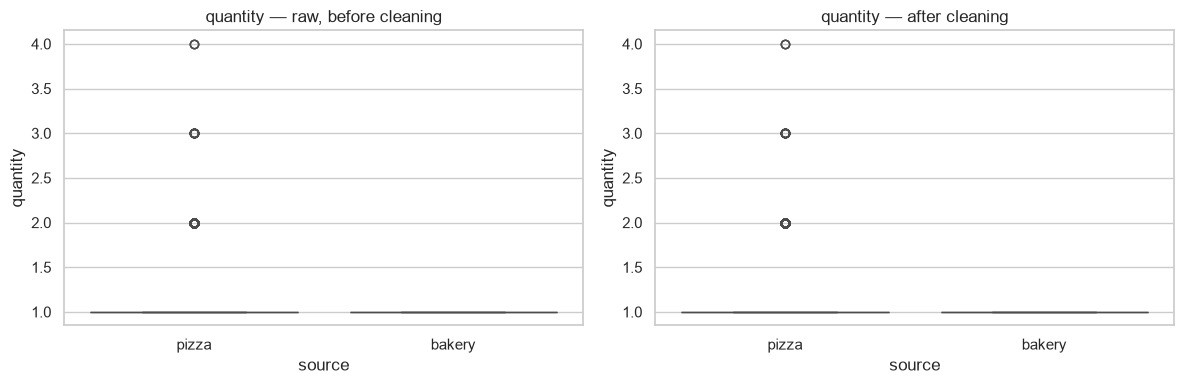

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=raw_combined, x="source", y="quantity", ax=axes[0])
axes[0].set_title("quantity — raw, before cleaning")
sns.boxplot(data=combined_clean, x="source", y="quantity", ax=axes[1])
axes[1].set_title("quantity — after cleaning")
plt.tight_layout()
plt.show()

### STEP 3 — Data Preprocessing

In [34]:
def aggregate_to_daily_item_level(df):
    return (
        df.groupby(["source", "item_name", "category", "date"], as_index=False)
        .agg(
            quantity_sold=("quantity", "sum"),
            revenue=("revenue", lambda s: s.sum(min_count=1)),  # stays NaN if all-NaN, not silently 0
        )
    )

def fill_date_gaps(daily):
    parts = []
    for (source, item, category), group in daily.groupby(["source", "item_name", "category"]):
        full_range = pd.date_range(group["date"].min(), group["date"].max(), freq="D")
        g = group.set_index("date").reindex(full_range)
        g["source"], g["item_name"], g["category"] = source, item, category
        g["quantity_sold"] = g["quantity_sold"].fillna(0)
        g.index.name = "date"
        parts.append(g.reset_index())
    return pd.concat(parts, ignore_index=True)

combined_clean = pd.concat([pizza_clean, bakery_clean], ignore_index=True)
daily = fill_date_gaps(aggregate_to_daily_item_level(combined_clean))
daily["day_of_week"] = daily["date"].dt.dayofweek
daily

,date,source,item_name,category,quantity_sold,revenue,day_of_week
0,2016-09-11,bakery,Adjustment,bakery_item,1.0,NaN,6
1,2017-01-14,bakery,Afternoon with the baker,bakery_item,3.0,NaN,5
2,2017-01-15,bakery,Afternoon with the baker,bakery_item,0.0,NaN,6
3,2017-01-16,bakery,Afternoon with the baker,bakery_item,1.0,NaN,0
4,2017-01-17,bakery,Afternoon with the baker,bakery_item,0.0,NaN,1
...,...,...,...,...,...,...,...
43388,2015-12-27,pizza,The Vegetables + Vegetables Pizza,Veggie,9.0,140.50,6
43389,2015-12-28,pizza,The Vegetables + Vegetables Pizza,Veggie,3.0,48.25,0
43390,2015-12-29,pizza,The Vegetables + Vegetables Pizza,Veggie,1.0,20.25,1
43391,2015-12-30,pizza,The Vegetables + Vegetables Pizza,Veggie,5.0,64.00,2


### EDA — days of history per item, weekly seasonality

23 of 126 items have < 60 days


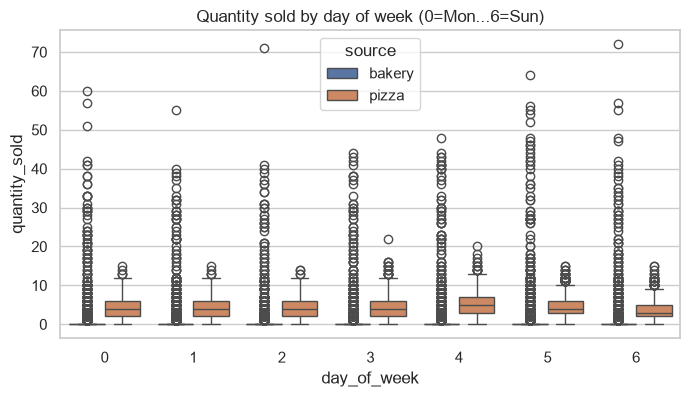

In [35]:
item_history = (
    daily.groupby(["source", "item_name"])
    .agg(days_of_data=("date", "nunique"))
    .reset_index().sort_values("days_of_data")
)
print((item_history["days_of_data"] < 60).sum(), "of", len(item_history), "items have < 60 days")

fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=daily, x="day_of_week", y="quantity_sold", hue="source", ax=ax)
ax.set_title("Quantity sold by day of week (0=Mon...6=Sun)")
plt.show()

## STEP 4 — Feature Engineering

In [36]:
def add_features(daily, lags=(1, 7), windows=(7, 14)):
    daily = daily.sort_values(["source", "item_name", "date"]).copy()
    daily["is_weekend"] = daily["day_of_week"].isin([5, 6])
    for lag in lags:
        daily[f"quantity_lag_{lag}"] = daily.groupby(["source", "item_name"])["quantity_sold"].shift(lag)
    for w in windows:
        daily[f"quantity_rolling_avg_{w}"] = (
            daily.groupby(["source", "item_name"])["quantity_sold"]
            .transform(lambda s: s.shift(1).rolling(w, min_periods=1).mean())
        )
    return daily

daily_features = add_features(daily)
daily_features

,date,source,item_name,category,quantity_sold,revenue,day_of_week,is_weekend,quantity_lag_1,quantity_lag_7,quantity_rolling_avg_7,quantity_rolling_avg_14
0,2016-09-11,bakery,Adjustment,bakery_item,1.0,NaN,6,True,NaN,NaN,NaN,NaN
1,2017-01-14,bakery,Afternoon with the baker,bakery_item,3.0,NaN,5,True,NaN,NaN,NaN,NaN
2,2017-01-15,bakery,Afternoon with the baker,bakery_item,0.0,NaN,6,True,3.0,NaN,3.000000,3.000000
3,2017-01-16,bakery,Afternoon with the baker,bakery_item,1.0,NaN,0,False,0.0,NaN,1.500000,1.500000
4,2017-01-17,bakery,Afternoon with the baker,bakery_item,0.0,NaN,1,False,1.0,NaN,1.333333,1.333333
...,...,...,...,...,...,...,...,...,...,...,...,...
43388,2015-12-27,pizza,The Vegetables + Vegetables Pizza,Veggie,9.0,140.50,6,True,3.0,4.0,2.714286,3.785714
43389,2015-12-28,pizza,The Vegetables + Vegetables Pizza,Veggie,3.0,48.25,0,False,9.0,2.0,3.428571,4.071429
43390,2015-12-29,pizza,The Vegetables + Vegetables Pizza,Veggie,1.0,20.25,1,False,3.0,2.0,3.571429,3.857143
43391,2015-12-30,pizza,The Vegetables + Vegetables Pizza,Veggie,5.0,64.00,2,False,1.0,5.0,3.428571,3.642857


### EDA — correlation matrix of engineered features

Checking how the lag and rolling-average features actually relate to the
target (quantity_sold) and each other, before trusting them as model
inputs. High correlation between quantity_sold and its own lags is
expected and good — it's the signal Prophet and any future model would
rely on. High correlation *between* the lag features themselves (e.g.
lag_1 vs rolling_avg_7) is also expected, not a problem, since Prophet
only uses ds/y directly — these engineered columns are for EDA and for any
future non-Prophet model, not fed into Prophet itself.


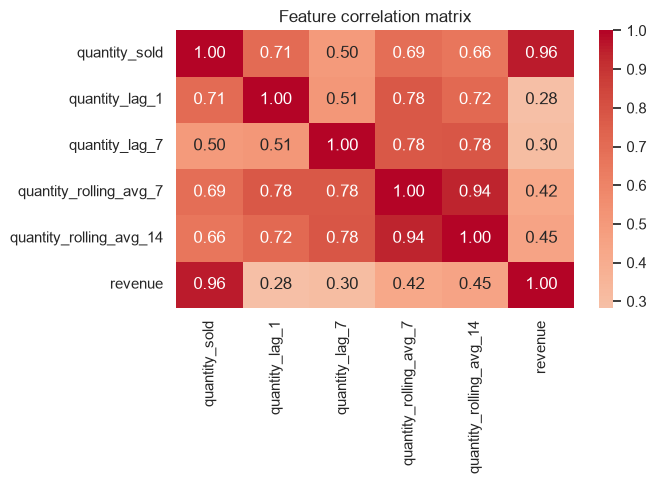

In [43]:
numeric_cols = [
    "quantity_sold", "quantity_lag_1", "quantity_lag_7",
    "quantity_rolling_avg_7", "quantity_rolling_avg_14", "revenue",
]
corr_df = daily_features[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

## Normalization

**Important distinction:** Prophet trains directly on the raw quantity_sold
scale. Prophet's own internal math handles trend and seasonality
decomposition on real units, and scaling y would only make the output
harder to interpret — "predicted demand: 0.42" means nothing to a shop
owner, "predicted demand: 12 units" does. **quantity_sold is never
normalized in this pipeline.**

What DOES get normalized: the engineered feature columns (lags, rolling
averages, revenue where available). These aren't fed into Prophet, but
normalizing them here (a) keeps them ready for any future non-Prophet
model without redoing this step, and (b) is where a bug would need to be
caught before it reached a model — verified below via before/after summary
stats, not just assumed to have worked.

In [44]:
feature_cols_to_scale = ["quantity_lag_1", "quantity_lag_7", "quantity_rolling_avg_7", "quantity_rolling_avg_14"]

# Rows with NaN lag values (the first few days of each item's series,
# before a lag/rolling window has enough history) can't be scaled — drop
# them for this step rather than silently filling with 0, which would
# fabricate a fake "low" value where the real answer is "unknown yet."
scale_ready = daily_features.dropna(subset=feature_cols_to_scale).copy()

print("Before scaling:")
print(scale_ready[feature_cols_to_scale].describe().loc[["min", "max", "mean"]])

scaler = MinMaxScaler()
scale_ready[feature_cols_to_scale] = scaler.fit_transform(scale_ready[feature_cols_to_scale])

print("\nAfter scaling (should be min=0, max=1 for every column):")
print(scale_ready[feature_cols_to_scale].describe().loc[["min", "max", "mean"]])

joblib.dump(scaler, FEATURE_SCALER_PATH)
print(f"\nscaler saved to {FEATURE_SCALER_PATH}")

Before scaling:
      quantity_lag_1  quantity_lag_7  quantity_rolling_avg_7  \
min         0.000000        0.000000                0.000000   
max        72.000000       72.000000               42.714286   
mean        1.605122        1.618783                1.606882   

      quantity_rolling_avg_14  
min                  0.000000  
max                 39.285714  
mean                 1.615509  

After scaling (should be min=0, max=1 for every column):
      quantity_lag_1  quantity_lag_7  quantity_rolling_avg_7  \
min         0.000000        0.000000                0.000000   
max         1.000000        1.000000                1.000000   
mean        0.022293        0.022483                0.037619   

      quantity_rolling_avg_14  
min                  0.000000  
max                  1.000000  
mean                 0.041122  

scaler saved to C:\Users\Kunal\ProjectCapstone\ml-service\app\data\processed\feature_scaler.joblib


## Save outputs — handoff to app/modeling/

In [37]:
daily_features.to_csv(SALES_DAILY_PROCESSED_CSV, index=False)
print(f"saved: {SALES_DAILY_PROCESSED_CSV} ({daily_features.shape[0]} rows)")

saved: C:\Users\Kunal\ProjectCapstone\ml-service\app\data\processed\sales_daily.csv (43393 rows)


In [38]:
sparse_items = item_history[item_history["days_of_data"] < 60]
print(sparse_items.to_string(index=False))

source                     item_name  days_of_data
bakery                    Adjustment             1
bakery                         Bacon             1
bakery                  Chicken sand             1
bakery                 Caramel bites             1
bakery                  Gift voucher             1
bakery                Olum & polenta             1
bakery                Hack the stack             1
bakery                       Pintxos             1
bakery                       Polenta             1
bakery                        Tshirt             1
bakery                      The BART             1
bakery                      Siblings             1
bakery                      Raw bars             1
bakery                      Postcard             1
bakery                      Panatone             3
bakery Raspberry shortbread sandwich             3
bakery                  Kids biscuit             7
bakery                      Mortimer            14
bakery               Chimichurr